In [1]:
from dft_ab import run_dft_ab
from gpaw import restart
from gpaw.new.ase_interface import ASECalculator
import ase
from extract_pi_dft_bands import save_pi_dft_bands, load_pi_dft_bands

In [6]:
import os.path
os.path.isfile('../gpw/ab.gpw')

True

In [2]:
filename = 'ab.gpw'

In [ ]:
run_dft_ab(filename)

In [3]:
filepath = '../gpw/' + filename

## DFT

In [4]:
atoms, calc = restart(filepath)
atoms: ase.atoms.Atoms # for hints
calc: ASECalculator

In [14]:
save_pi_dft_bands(atoms, calc)

[[ 1.27707018 -0.73731681  0.        ]
 [ 1.20612184 -0.86020295  0.        ]
 [ 1.1351735  -0.98308909  0.        ]
 [ 1.06422515 -1.10597522  0.        ]
 [ 0.99327681 -1.22886136  0.        ]
 [ 0.92232847 -1.35174749  0.        ]
 [ 0.85138012 -1.47463363  0.        ]
 [ 0.78588934 -1.36120027  0.        ]
 [ 0.72039857 -1.24776692  0.        ]
 [ 0.65490779 -1.13433356  0.        ]
 [ 0.58941701 -1.02090021  0.        ]
 [ 0.52392623 -0.90746685  0.        ]
 [ 0.45843545 -0.79403349  0.        ]
 [ 0.39294467 -0.68060014  0.        ]
 [ 0.32745389 -0.56716678  0.        ]
 [ 0.26196311 -0.45373342  0.        ]
 [ 0.19647234 -0.34030007  0.        ]
 [ 0.13098156 -0.22686671  0.        ]
 [ 0.06549078 -0.11343336  0.        ]
 [ 0.          0.          0.        ]]
π-band indices: [7 8 6 9]


In [5]:
kpts, E_pi, band_energies, EF = load_pi_dft_bands()

## TB

In [7]:
from tb_bands import TBBandManager
import numpy as np
theta0 = np.array([
            3.1,  # gamma0
            0.39,  # gamma1
            0.315,  # gamma3
            0.044,  # gamma4
            0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
        ])
manager = TBBandManager(atoms)

manager.create_3d_plot(theta0)


File saved in ../data/3d_bands.html


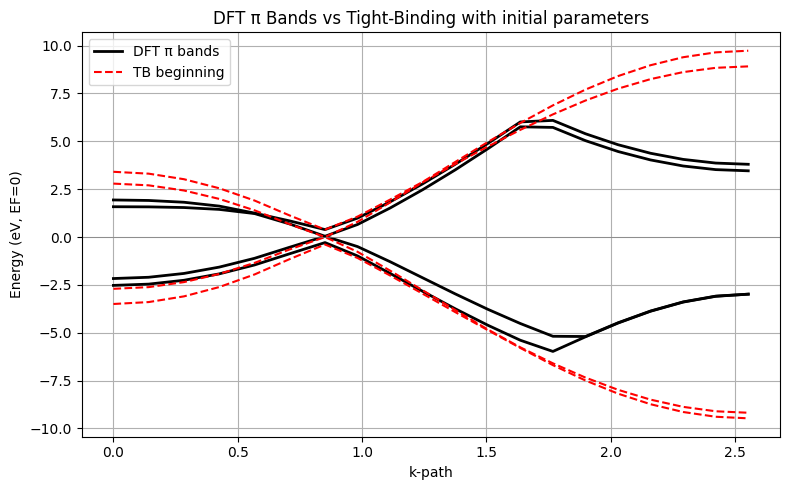

In [16]:
import matplotlib.pyplot as plt

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)

plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_0[:, i], 'r--', lw=1.5, label="TB beginning" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
from tb_parameters_optimizer import optimize
E_pi_ordered = E_pi[:, [2, 0, 1, 3]] # IMPORTANT! Must reorder bands so that they match from the two models.

theta_fit = optimize(manager, theta0, kpts, E_pi_ordered, 0.5, 1.5)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.4182e+00                                    4.70e+00    
       1              3         3.3682e-01      1.08e+00       7.85e-01       5.71e-01    
       2              4         2.0330e-01      1.34e-01       6.36e-01       4.22e-01    
       3              5         1.8148e-01      2.18e-02       2.14e-01       5.34e-02    
       4              6         1.8075e-01      7.30e-04       1.10e-01       3.03e-02    
       5              7         1.7995e-01      8.04e-04       2.74e-02       1.38e-02    
       6              8         1.7994e-01      1.24e-05       4.80e-02       1.63e-02    
       7              9         1.7977e-01      1.67e-04       1.20e-02       5.49e-03    
       8             10         1.7976e-01      6.79e-06       2.13e-02       4.41e-03    
       9             11         1.7974e-01      2.92e-05       5.32e-03       2.42e-03    

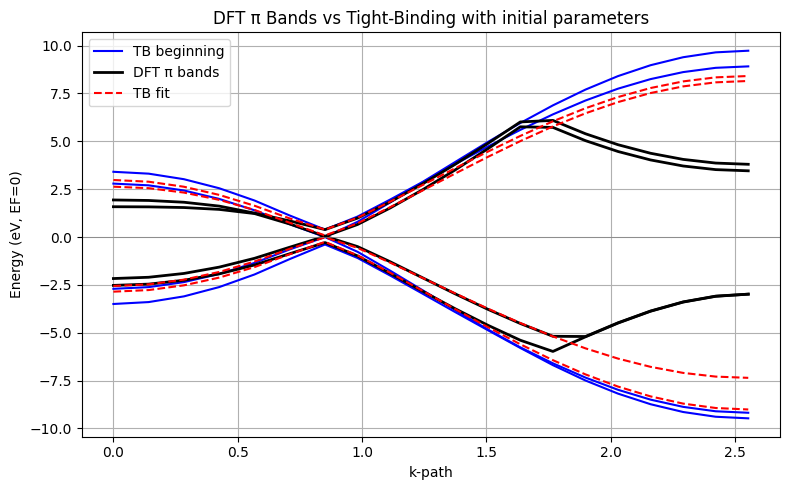

In [11]:
import matplotlib.pyplot as plt

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)
E_tb_fit = manager.tb_bands(kpts, theta_fit)


plt.figure(figsize=(8,5))

nb = E_pi.shape[1]

for i in range(nb):
    plt.plot(x, E_tb_0[:, i], 'b-', lw=1.5, label="TB beginning" if i==0 else "")

# DFT π bands
for i in range(nb):
    plt.plot(x, E_pi[:, i], 'k-', lw=2, label="DFT π bands" if i==0 else "")

# TB π bands
for i in range(4):
    plt.plot(x, E_tb_fit[:, i], 'r--', lw=1.5, label="TB fit" if i==0 else "")

plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("k-path")
plt.ylabel("Energy (eV, EF=0)")
plt.title("DFT π Bands vs Tight-Binding with initial parameters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()